# Mobile Game Retention A/B Test
## Does moving the first gate improve retention?
### 90,189 players · level 30 vs level 40 · retention and engagement

**Recommendation: keep the first gate at level 30, pending allocation and data-quality verification.** Day-7 retention is 19.02% in the control group and 18.20% in the treatment group: a difference of −0.82 percentage points (95% CI: −1.33 to −0.31 pp). Moving the gate later does not show a clear engagement benefit.

This project evaluates a mobile game's progression-gate experiment using player-level outcomes. Sections 1–8 cover the business question, data checks, effect estimates, and recommendation. Day-7 retention is the only primary outcome. Day-1 retention and game rounds are exploratory supporting analyses; their p-values are not used to claim additional discoveries.

**Notation**

| Term | Meaning |
|---|---|
| Control | `gate_30`: first gate at level 30 |
| Treatment | `gate_40`: first gate at level 40 |
| Difference | Treatment minus control; negative retention differences favor control |
| Percentage point (pp) | Difference between percentages: 20% to 19% is −1 pp |
| Relative change | Difference divided by the control rate: 20% to 19% is −5% |
| 95% CI | Confidence interval describing uncertainty in an estimated difference |
| p-value | Under the no-difference model, the probability of a test statistic at least as extreme as observed; not the probability the null is true |

A 95% confidence procedure covers the true parameter in 95% of repeated samples under its assumptions. It is not a posterior probability for a particular interval.


## 1. Setup and data

**Data source:** [gate_experiment.csv on Google Drive](https://drive.google.com/file/d/1CVMsQtjLeW-pf_LN0cm5zlaWTn1tjeyF/view?usp=sharing).

Run the notebook from the extracted project root or `notebooks/`. The code reads `data/gate_experiment.csv` when present and downloads it from the public link otherwise. No Drive mounting, ZIP extraction, or archive creation is performed by the notebook.

**Colab:** Run all works without connecting Drive; files are saved in the runtime project folder. To save results directly into an existing Drive project, first connect Drive through Colab's Files panel. A project at `My Drive/Mobile_game_retention_ABtest/` is detected automatically. For another location, set `PROJECT_PATH` in the setup cell. Check the printed **Project folder** before continuing. Merely opening a notebook stored in Drive does not connect the runtime to its surrounding files.

The data has one row per player, a group label, recorded rounds, and day-1/day-7 return indicators. The exact rounds observation window is not encoded in the CSV. Random assignment and independent player observations are assumptions for inference. Assignment logs, intended allocation ratio, test dates, exposure events, and revenue are unavailable.


In [45]:
# ---------- Imports ----------
from pathlib import Path
import sys
import subprocess
import hashlib
import json
import platform
import sqlite3

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from IPython.display import display, Markdown


# ---------- Analysis settings ----------
CONTROL = "gate_30"
TREATMENT = "gate_40"

ALPHA = 0.05
SEED = 42
N_BOOT = 10_000
Z_CRIT = stats.norm.ppf(1 - ALPHA / 2)


# ---------- Project folders ----------
PROJECT_NAME = "Mobile_game_retention_ABtest"

try:
    from google.colab import drive
except ImportError:
    # Local Jupyter: launch from the project root or notebooks/.
    cwd = Path.cwd()
    PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
else:
    # Colab: connect Drive and save results to the existing project.
    drive.mount("/content/drive")

    PROJECT_DIR = (
        Path("/content/drive/MyDrive/DS_Project_Portfolio")
        / PROJECT_NAME
    )

    if not PROJECT_DIR.is_dir():
        raise FileNotFoundError(
            f"Project folder not found: {PROJECT_DIR}\n"
            "Check that the folder name and location match your Google Drive."
        )

# Prefer the existing capitalized Data folder.
# Support lowercase data/ for local repository layouts.
if (PROJECT_DIR / "Data").is_dir():
    DATA_DIR = PROJECT_DIR / "Data"
elif (PROJECT_DIR / "data").is_dir():
    DATA_DIR = PROJECT_DIR / "data"
else:
    DATA_DIR = PROJECT_DIR / "Data"

FIG_DIR = PROJECT_DIR / "figures"
OUT_DIR = PROJECT_DIR / "outputs"

for folder in [DATA_DIR, FIG_DIR, OUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# ---------- Read or download data ----------
DATA_FILE_ID = "1CVMsQtjLeW-pf_LN0cm5zlaWTn1tjeyF"
DATA_PATH = DATA_DIR / "gate_experiment.csv"

required_columns = {
    "userid",
    "version",
    "sum_gamerounds",
    "retention_1",
    "retention_7",
}

if not DATA_PATH.is_file():
    try:
        import gdown
    except ImportError:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "gdown==5.2.0",
        ])
        import gdown

    temporary_path = DATA_DIR / "gate_experiment.download"

    try:
        downloaded = gdown.download(
            id=DATA_FILE_ID,
            output=str(temporary_path),
            quiet=False,
            use_cookies=False,
        )

        if downloaded is None or not temporary_path.is_file():
            raise RuntimeError("The download did not complete.")

        downloaded_columns = pd.read_csv(
            temporary_path, nrows=0
        ).columns

        if not required_columns.issubset(downloaded_columns):
            raise ValueError(
                "The downloaded file does not contain the expected columns."
            )

        temporary_path.replace(DATA_PATH)

    except Exception as error:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            "Automatic download failed. Download gate_experiment.csv "
            "from the README data-source link and place it at:\n"
            f"{DATA_PATH}"
        ) from error

raw = pd.read_csv(DATA_PATH)

missing_columns = required_columns - set(raw.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")


# ---------- Plot settings ----------
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    CONTROL: "#286090",
    TREATMENT: "#cf6b35",
}


def save_figure(name):
    """Save the current figure to the project folder and display it."""
    plt.tight_layout()
    plt.savefig(
        FIG_DIR / name,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()


# ---------- Confirm paths and environment ----------
print("Project folder:", PROJECT_DIR)
print("Data file:", DATA_PATH)
print("Figures saved to:", FIG_DIR)
print("Outputs saved to:", OUT_DIR)

print(f"\nLoaded {len(raw):,} players × {raw.shape[1]} columns.")

print("\nPython:", platform.python_version())
print(
    "NumPy:", np.__version__,
    "| pandas:", pd.__version__,
    "| SciPy:", scipy.__version__,
    "| matplotlib:", matplotlib.__version__,
)

display(raw.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/DS_Project_Portfolio/Mobile_game_retention_ABtest
Data file: /content/drive/MyDrive/DS_Project_Portfolio/Mobile_game_retention_ABtest/Data/gate_experiment.csv
Figures saved to: /content/drive/MyDrive/DS_Project_Portfolio/Mobile_game_retention_ABtest/figures
Outputs saved to: /content/drive/MyDrive/DS_Project_Portfolio/Mobile_game_retention_ABtest/outputs

Loaded 90,189 players × 5 columns.

Python: 3.13.15
NumPy: 2.1.3 | pandas: 2.2.3 | SciPy: 1.16.3 | matplotlib: 3.10.0


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 2. Question, metrics, and data integrity
**Question:** Is moving the first gate associated with improved retention, under the stated random-assignment assumption?

| Role in this analysis | Metric | Purpose |
|---|---|---|
| Primary | Day-7 retention | Main decision metric |
| Exploratory supporting | Day-1 retention | Early return behavior |
| Exploratory supporting | Recorded game rounds | Engagement; report raw and capped versions separately |
| Missing guardrail | Revenue per player | Needed to evaluate a retention–monetization trade-off |

These roles define this analysis; the original experiment's prespecified metric hierarchy is unavailable. Tests are two-sided because both improvement and harm matter. Keeping the existing gate is the provisional default when evidence for improvement is absent; a production launch would also need a minimum worthwhile benefit, guardrails, and validated data.

**Why this step?** Correct formulas cannot rescue invalid input. We check the schema and values before computing results.


Only Day-7 retention supports the primary statistical conclusion. Supporting metrics provide context; no additional discovery claims are based on their p-values. The original metric plan remains unavailable.


In [46]:
raw = pd.read_csv(DATA_PATH)
required = {"userid", "version", "sum_gamerounds", "retention_1", "retention_7"}
assert required.issubset(raw.columns), "Missing required columns"
assert not raw[list(required)].isna().any().any(), "Missing values require investigation"
assert raw.userid.is_unique, "Duplicate player IDs require investigation"
assert set(raw.version.unique()) == {CONTROL, TREATMENT}, "Unexpected variants"
assert pd.api.types.is_numeric_dtype(raw.sum_gamerounds), "Rounds must be numeric"
assert np.isfinite(raw.sum_gamerounds).all(), "Non-finite rounds"
assert raw.sum_gamerounds.ge(0).all(), "Negative rounds"
assert raw.sum_gamerounds.mod(1).eq(0).all(), "Non-integer rounds"
for metric in ["retention_1", "retention_7"]:
    assert raw[metric].isin([True, False, 0, 1]).all(), f"Invalid binary values: {metric}"
df = raw.copy()
df[["retention_1", "retention_7"]] = df[["retention_1", "retention_7"]].astype(int)
counts = df.groupby("version").size().reindex([CONTROL, TREATMENT])
display(pd.DataFrame({"players": counts, "share (%)": 100 * counts / len(df)}).round(2))
print(f"Validated {len(df):,} unique players with no missing required values.")
print("Zero-round players retained:", df.sum_gamerounds.eq(0).sum())
print("Returned on day 7 but not day 1:", ((df.retention_7 == 1) & (df.retention_1 == 0)).sum())


,players,share (%)
version,,
gate_30,44700,49.56
gate_40,45489,50.44


Validated 90,189 unique players with no missing required values.
Zero-round players retained: 3994
Returned on day 7 but not day 1: 3599


**Keep all assigned players.** The analysis follows the intent-to-treat principle within the extract: players remain in their assigned group, including zero-round players. We cannot verify whether the extract itself contains every originally assigned player.

Day-1 and day-7 flags refer to separate days. Returning on day 7 without returning on day 1 is not a data error. A round is a play attempt, not a level reached.


## 3. Allocation diagnostic: a conditional SRM check
**Why this step?** If the intended split was 50/50, a large departure could indicate assignment, logging, or filtering issues. Different sample sizes by themselves do not invalidate a two-sample test.

We use a chi-square goodness-of-fit test **conditional on an assumed 50/50 design**. The original ratio is unavailable. The 1% review threshold below is an explicit diagnostic choice for this analysis, not a universal platform standard or the original experiment's rule.


In [47]:
ASSUMED_CONTROL_SHARE = 0.50
SRM_REVIEW_ALPHA = 0.01
srm = stats.chisquare(counts.to_numpy(), f_exp=len(df) * np.array([ASSUMED_CONTROL_SHARE, 1 - ASSUMED_CONTROL_SHARE]))
print(f"Assumed control share: {ASSUMED_CONTROL_SHARE:.0%}")
print(f"SRM p-value: {srm.pvalue:.4f}")
print("Review flagged under this assumption:", srm.pvalue < SRM_REVIEW_ALPHA)

zero = df.assign(zero_rounds=df.sum_gamerounds.eq(0)).groupby("version").zero_rounds.agg(["sum", "count"])
zero_table = np.column_stack([zero["sum"], zero["count"] - zero["sum"]])
zero_p = stats.chi2_contingency(zero_table, correction=False).pvalue
print("Zero-round shares (%):")
print((100 * zero["sum"] / zero["count"]).round(2).to_string())
print(f"Zero-round diagnostic p-value: {zero_p:.3f}")


Assumed control share: 50%
SRM p-value: 0.0086
Review flagged under this assumption: True
Zero-round shares (%):
version
gate_30    4.33
gate_40    4.52
Zero-round diagnostic p-value: 0.169


**Interpretation:** The allocation deserves investigation if 50/50 was intended. It is not proof of an assignment bug. The zero-round comparison detects no clear difference, but cannot establish group equivalence or clear an SRM concern. Zero rounds is a post-assignment diagnostic, not a verified pretreatment invariant; logging or variant startup behavior could affect it.

The following estimates are **provisional, conditional on a valid experiment and complete data**. A real review would confirm intended allocation and check counts by date, device, country, and acquisition channel using assignment and event logs. None of those checks is possible from this CSV.


## 4. Explore engagement without deleting players
**Why this step?** A few very large round counts can dominate the mean. We inspect the distribution before deciding what a summary represents. No player is removed from the retention analysis.


,count,mean,median,std,max
version,,,,,
gate_30,44700,52.46,17.0,256.72,49854
gate_40,45489,51.30,16.0,103.29,2640


,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,0,1
7912,871500,gate_30,2961,1,1
29417,3271615,gate_40,2640,1,0


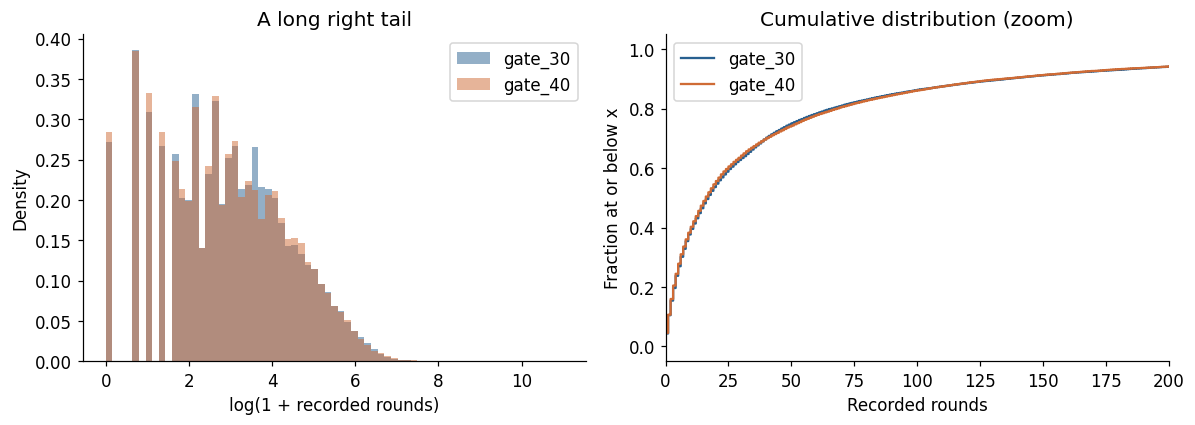

In [48]:
display(df.groupby("version").sum_gamerounds.agg(["count", "mean", "median", "std", "max"]).round(2))
display(df.nlargest(3, "sum_gamerounds"))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for variant in [CONTROL, TREATMENT]:
    values = df.loc[df.version.eq(variant), "sum_gamerounds"].to_numpy()
    axes[0].hist(np.log1p(values), bins=np.linspace(0, 11, 70), density=True,
                 alpha=0.5, label=variant, color=COLORS[variant])
    sorted_values = np.sort(values)
    axes[1].step(sorted_values, np.arange(1, len(values) + 1) / len(values),
                 where="post", label=variant, color=COLORS[variant])
axes[0].set(xlabel="log(1 + recorded rounds)", ylabel="Density", title="A long right tail")
axes[1].set(xlim=(0, 200), xlabel="Recorded rounds", ylabel="Fraction at or below x", title="Cumulative distribution (zoom)")
axes[0].legend(); axes[1].legend()
save_figure("01_rounds_distribution.png")


The largest record is 49,854 rounds, far above the next largest. It is suspicious, but the extract cannot establish whether it is an error, automation, or genuine activity. We keep it and report sensitivity to capping.

**Winsorization (capping):** replace values above a common threshold with that threshold, without deleting users. This changes the quantity being estimated. A capped mean is not actual average gameplay, and values above the cap become tied.

For this sensitivity analysis, we use the pooled 99th percentile. It is data-dependent, so it is not a preregistered, treatment-independent threshold. A future experiment should use a justified historical fixed threshold. The confidence interval for capped rounds below treats the observed cap as fixed; it does not include uncertainty from selecting that cap.


In [49]:
cap = float(df.sum_gamerounds.quantile(0.99))
df["rounds_capped"] = df.sum_gamerounds.clip(upper=cap)
print(f"Common cap: {cap:.0f} rounds; {(df.sum_gamerounds > cap).sum():,} records capped.")

def welch_result(column):
    control = df.loc[df.version.eq(CONTROL), column]
    treatment = df.loc[df.version.eq(TREATMENT), column]
    test = stats.ttest_ind(treatment, control, equal_var=False)
    ci = test.confidence_interval(confidence_level=1 - ALPHA)
    return {"control_mean": control.mean(), "treatment_mean": treatment.mean(),
            "difference": treatment.mean() - control.mean(),
            "ci_low": ci.low, "ci_high": ci.high, "p_value": test.pvalue}
rounds_results = pd.DataFrame({"Raw rounds": welch_result("sum_gamerounds"),
                              "Capped rounds (sensitivity)": welch_result("rounds_capped")}).T
display(rounds_results.round(4))


Common cap: 493 rounds; 898 records capped.


,control_mean,treatment_mean,difference,ci_low,ci_high,p_value
Raw rounds,52.4563,51.2988,-1.1575,-3.7197,1.4047,0.3759
Capped rounds (sensitivity),49.1358,48.8539,-0.2819,-1.3811,0.8173,0.6152


**How to interpret this:** Neither analysis provides clear evidence of a mean difference. This is not an equivalence test and does not prove that any effect is unimportant. The capped result applies to capped rounds only. The raw Welch interval is particularly sensitive to the extreme tail and should be treated cautiously.

Welch compares means without assuming equal group variances. Approximate inference depends on how well the means behave, not on raw observations being exactly normal. A large sample helps but does not guarantee robustness to extreme tails. We do not choose the research question using a Shapiro test or declare a t-test “fixed” using a skewness rule.


## 5. Primary analysis: day-7 retention
**Why this step?** A retention rate is the average of 0/1 player outcomes. The two-proportion z-test checks a no-difference model; a confidence interval describes the estimated difference and its uncertainty.

For the test, the standard error uses a pooled rate because the null assumes equal rates. For the interval, it uses separate group rates without imposing that null. These are large-sample approximations; both groups have many retained and non-retained players.

All displayed retention differences and intervals are in **percentage points**. Relative change is reported separately.


,Control (%),Treatment (%),Difference (pp),CI low (pp),CI high (pp),Relative change (%),p-value
retention_7,19.0201,18.2000,-0.8201,-1.3282,-0.3121,-4.3119,0.0016
retention_1,44.8188,44.2283,-0.5905,-1.2392,0.0582,-1.3176,0.0744


**Day 7:** -0.82 pp (95% CI -1.33 to -0.31), p = 0.0016. The interval excludes zero. **Day 1:** -0.59 pp (95% CI -1.24 to +0.06), p = 0.0744. This interval includes zero.

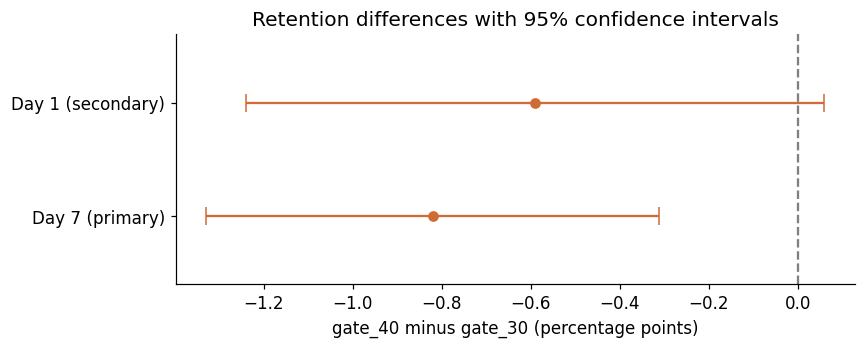

In [50]:
def retention_result(metric):
    grouped = df.groupby("version")[metric].agg(["sum", "count"])
    x_c, n_c = grouped.loc[CONTROL, ["sum", "count"]]
    x_t, n_t = grouped.loc[TREATMENT, ["sum", "count"]]
    p_c, p_t = x_c / n_c, x_t / n_t
    difference = p_t - p_c
    p_pool = (x_c + x_t) / (n_c + n_t)
    se_null = np.sqrt(p_pool * (1 - p_pool) * (1 / n_c + 1 / n_t))
    se_ci = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
    z = difference / se_null
    return {"control_rate": p_c, "treatment_rate": p_t, "difference": difference,
            "ci_low": difference - Z_CRIT * se_ci, "ci_high": difference + Z_CRIT * se_ci,
            "relative_change": difference / p_c, "p_value": 2 * stats.norm.sf(abs(z))}
retention = pd.DataFrame({m: retention_result(m) for m in ["retention_7", "retention_1"]}).T
retention_display = pd.DataFrame({
    "Control (%)": retention.control_rate * 100,
    "Treatment (%)": retention.treatment_rate * 100,
    "Difference (pp)": retention.difference * 100,
    "CI low (pp)": retention.ci_low * 100,
    "CI high (pp)": retention.ci_high * 100,
    "Relative change (%)": retention.relative_change * 100,
    "p-value": retention.p_value})
display(retention_display.round(4))
r7 = retention.loc["retention_7"]
r1 = retention.loc["retention_1"]
display(Markdown(f"**Day 7:** {r7.difference * 100:+.2f} pp (95% CI {r7.ci_low * 100:+.2f} to {r7.ci_high * 100:+.2f}), p = {r7.p_value:.4f}. The interval excludes zero. **Day 1:** {r1.difference * 100:+.2f} pp (95% CI {r1.ci_low * 100:+.2f} to {r1.ci_high * 100:+.2f}), p = {r1.p_value:.4f}. This interval includes zero."))
fig, ax = plt.subplots(figsize=(8, 3.3))
for y, metric in enumerate(["retention_7", "retention_1"]):
    r = retention.loc[metric]
    ax.errorbar(r.difference * 100, y,
                xerr=[[100 * (r.difference - r.ci_low)], [100 * (r.ci_high - r.difference)]],
                fmt="o", capsize=6, color=COLORS[TREATMENT])
ax.axvline(0, color="gray", linestyle="--")
ax.set(yticks=[0, 1], yticklabels=["Day 7 (primary)", "Day 1 (secondary)"],
       xlabel="gate_40 minus gate_30 (percentage points)", title="Retention differences with 95% confidence intervals", ylim=(-0.6, 1.6))
save_figure("02_retention_effects.png")


The day-1 interval permits both a decline and a near-zero effect. **Not significant does not mean no effect**, and it does not establish that insufficient sample size is the explanation.

The day-7 estimate is about 8 fewer returning players per 1,000 installs. This is a day-specific retention outcome, not continuous activity since installation or monthly active users. Statistical evidence for a difference does not identify the behavioral mechanism.


## 6. Cross-checks: SQL and bootstrap
**SQL:** reproduce the group counts and retained-player counts using the same extract. This checks aggregation consistency, not upstream data validity. This is not a reconstruction from a production event warehouse.


In [51]:
with sqlite3.connect(":memory:") as connection:
    df[["userid", "version", "retention_1", "retention_7"]].to_sql("players", connection, index=False)
    sql_counts = pd.read_sql_query("""
        SELECT version, COUNT(*) AS players,
               SUM(retention_1) AS retained_day_1,
               SUM(retention_7) AS retained_day_7
        FROM players
        GROUP BY version
        ORDER BY version
    """, connection).set_index("version")
expected = df.groupby("version").agg(players=("userid", "size"),
    retained_day_1=("retention_1", "sum"), retained_day_7=("retention_7", "sum"))
pd.testing.assert_frame_equal(sql_counts, expected, check_dtype=False)
display(sql_counts)


,players,retained_day_1,retained_day_7
version,,,
gate_30,44700,20034,8502
gate_40,45489,20119,8279


**Bootstrap:** imagine drawing another sample from the observed players in each group, with replacement, then recomputing the rate difference. Repeating this provides an approximate uncertainty interval without specifying a normal outcome distribution. It still relies on representative data and the independent-player resampling assumption; it cannot repair selection bias or interference.

For a binary outcome, the retained count in a resample of size n is exactly a Binomial draw with n trials and the observed retention rate. We use that shortcut rather than repeatedly copying thousands of rows. Each metric is analyzed separately; these marginal simulations do not preserve cross-metric correlations.


,CI low (pp),CI high (pp)
metric,,
retention_7,-1.331,-0.317
retention_1,-1.242,0.070


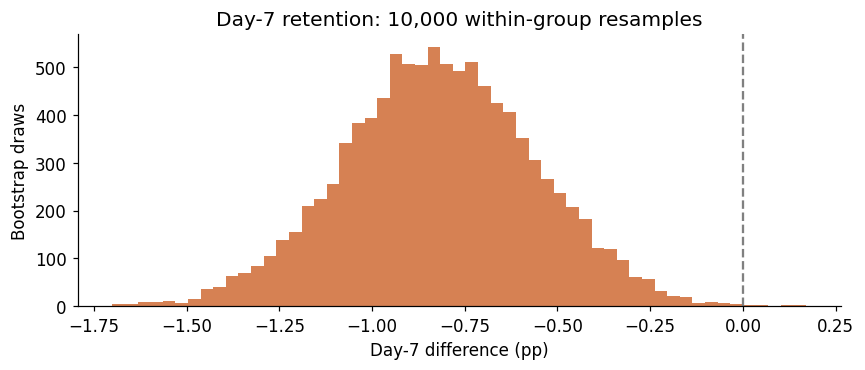

In [52]:
boot_rng = np.random.default_rng(SEED)
boot_differences = {}
boot_rows = []
for metric in ["retention_7", "retention_1"]:
    rates = retention.loc[metric]
    n_c, n_t = int(counts[CONTROL]), int(counts[TREATMENT])
    draws = (boot_rng.binomial(n_t, rates.treatment_rate, N_BOOT) / n_t
             - boot_rng.binomial(n_c, rates.control_rate, N_BOOT) / n_c)
    boot_differences[metric] = draws
    lo, hi = np.quantile(draws, [ALPHA / 2, 1 - ALPHA / 2])
    boot_rows.append({"metric": metric, "CI low (pp)": lo * 100, "CI high (pp)": hi * 100})
bootstrap_table = pd.DataFrame(boot_rows).set_index("metric")
display(bootstrap_table.round(3))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(boot_differences["retention_7"] * 100, bins=55, color=COLORS[TREATMENT], alpha=0.85)
ax.axvline(0, color="gray", linestyle="--")
ax.set(xlabel="Day-7 difference (pp)", ylabel="Bootstrap draws", title="Day-7 retention: 10,000 within-group resamples")
save_figure("03_day7_bootstrap.png")


The day-7 bootstrap and analytic intervals are similar. They use the same players, so agreement checks method sensitivity; it is not independent replication. The resampling distribution describes sampling uncertainty; the share of negative draws is not automatically a valid null-model p-value.


## 7. Recommendation and limits
**Provisional recommendation: retain the first gate at level 30.** The sample shows a day-7 retention decline with gate_40, and there is no clear compensating improvement in the recorded engagement metrics. This does not establish engagement equivalence.

Before an actual rollout decision:

1. Confirm the intended allocation ratio and investigate any mismatch using assignment and logging records.
2. Verify the rounds observation window and whether every player's day-7 observation is complete.
3. Add revenue per player and longer-term retention to evaluate the product trade-off.

Possible explanations, such as an earlier gate encouraging a break, remain hypotheses. This dataset cannot show why retention differs, predict revenue losses, or establish that a gate earlier than level 30 would help.

| Limitation | Consequence |
|---|---|
| Original metric plan unavailable | Cannot verify prespecification of metrics or analysis choices |
| No dates or assignment logs | Cannot verify stopping behavior, duration, maturity, or allocation implementation |
| Missing player characteristics | Cannot examine pretreatment covariate balance or explain the allocation diagnostic |
| Possible social interactions | Independent-player assumptions could fail; the extract cannot quantify interference |
| No pre-experiment behavior | No historical-outcome CUPED adjustment implemented |
| No revenue or day-30 outcomes | Monetization and long-term effects remain unknown |
| Outcome-based subgroups | Comparing only retained players or players reaching a gate would change the causal comparison; not used here |

**Illustrative scale only:** the calculation below assumes 500,000 new installs per month and that the estimated effect transports to those players. It is neither measured monthly loss nor an estimate of lost purchases.


In [53]:
MONTHLY_INSTALLS_ASSUMED = 500_000
business = {
    "monthly_installs_assumed": MONTHLY_INSTALLS_ASSUMED,
    "estimated_fewer_day7_returners": float(-r7.difference * MONTHLY_INSTALLS_ASSUMED),
    "ci_low": float(-r7.ci_high * MONTHLY_INSTALLS_ASSUMED),
    "ci_high": float(-r7.ci_low * MONTHLY_INSTALLS_ASSUMED)}
print(f"Illustrative fewer day-7 returners per monthly install cohort: {business['estimated_fewer_day7_returners']:,.0f}")
print(f"95% interval under the model: {business['ci_low']:,.0f} to {business['ci_high']:,.0f}")


Illustrative fewer day-7 returners per monthly install cohort: 4,101
95% interval under the model: 1,561 to 6,641


## 8. Decision summary and next experiment

| Question | Evidence | Decision implication |
|---|---|---|
| Does the later gate improve day-7 retention? | Difference −0.82 pp; the 95% interval is below zero | No evidence supporting a move to level 40; observed retention favors level 30 |
| Is there an engagement gain? | Raw and capped mean-round intervals both include zero | No clear compensating gain; equivalence is not established |
| Is the experiment ready for an unconditional rollout decision? | Allocation is flagged under a 50/50 assumption; assignment logs are absent | Verify intended allocation and data collection before acting |
| Is the revenue trade-off known? | No purchase or revenue fields | Add revenue per player as a guardrail |

For a follow-up experiment, define the minimum worthwhile retention improvement, choose a historical baseline for sample-size planning, collect revenue and day-30 outcomes, and specify the observation window and stopping rule before launch. A result favoring level 30 over level 40 does not establish that moving the gate earlier than level 30 would help.


## 9. Save results

The final cell saves unrounded CSV/JSON summaries under `outputs/`; plots are saved under `figures/`. All paths are relative to the **Project folder** printed in setup. No ZIP is created.

When working from a Drive notebook in Colab, use **File → Save** after running and wait for saving to finish before downloading the project folder. If you opened a separate copy, download the executed `.ipynb` and replace `notebooks/gate_experiment_analysis.ipynb` in your project. Files saved only in the Colab runtime are temporary; download them before ending the session.


In [54]:
retention.to_csv(OUT_DIR / "retention_results.csv", index_label="metric")
rounds_results.to_csv(OUT_DIR / "rounds_results.csv", index_label="metric")
bootstrap_table.to_csv(OUT_DIR / "bootstrap_intervals_pp.csv")
results = {
    "scope": "Player-level experiment analysis; conditional on valid assignment and complete data",
    "direction": "gate_40 minus gate_30",
    "retention_units": "Rates, differences and CI bounds are fractions; multiply by 100 for percent or pp",
    "data_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "n_players": len(df), "group_counts": {k: int(v) for k, v in counts.items()},
    "seed": SEED, "alpha": ALPHA, "bootstrap_draws": N_BOOT,
    "assumed_control_share": ASSUMED_CONTROL_SHARE, "srm_p_value": float(srm.pvalue),
    "zero_round_diagnostic_p_value": float(zero_p),
    "retention": retention.to_dict(orient="index"),
    "rounds": rounds_results.to_dict(orient="index"), "rounds_cap": cap,
    "bootstrap_intervals_pp": bootstrap_table.to_dict(orient="index"),
    "illustrative_business_scenario": business,
    "recommendation": "Provisionally keep gate_30; verify allocation and data integrity before acting",
    "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
                 "scipy": scipy.__version__, "matplotlib": matplotlib.__version__}}
(OUT_DIR / "results.json").write_text(json.dumps(results, indent=2, allow_nan=False) + "\n")
print("Saved 3 figures, 3 CSV summaries, and results.json.")

Saved 3 figures, 3 CSV summaries, and results.json.
